# Domain models — corrección: feature selection + tuning por dominio

El notebook `04` mostró que usar 96 features genéricas para los tres dominios hace que **VMS sufra ruido** (R² negativo) y que Sediment-Hosted no sea evaluable. La hipótesis es que cada tipo necesita:

1. **Su propio subset de features relevantes** (top-N por importance dentro del dominio).
2. **Sus propios hiperparámetros** (VMS necesita más regularización, Sediment-Hosted necesita árboles más chicos por poca data).

Acá hacemos ambas cosas y comparamos contra:
- Baseline global (`02`): R² test = 0.371, RMSE = 1.129
- Domaining v1 (`04`): RMSE Porphyry 0.213, VMS 1.283, Sediment 2.710

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

from src.features.build_features import build_feature_matrix
from src.training.domain_regressor import DomainRegressor

sns.set_style("whitegrid")
np.random.seed(42)

DATA_DIR = "../data/external/Global-copper-deposit-dataset/"
DOMAINS = ["Porphyry", "VMS", "Sediment-Hosted"]

## 1. Cargar datos y split (idéntico al notebook 04 para comparación justa)

In [2]:
X_all, y_log_all, deposit_type_all, feature_cols = build_feature_matrix(
    main_xlsx=DATA_DIR + "Global_Copper_Deposit_Main.xlsx",
    ages_xlsx=DATA_DIR + "MED_ages_reordered_20200131.xlsx",
)
mask = deposit_type_all.isin(DOMAINS)
X = X_all.loc[mask].reset_index(drop=True)
y_log = y_log_all.loc[mask].reset_index(drop=True)
groups = deposit_type_all.loc[mask].reset_index(drop=True)

X_train, X_test, y_train_log, y_test_log, g_train, g_test = train_test_split(
    X, y_log, groups, test_size=0.2, stratify=groups, random_state=42
)
y_test = np.expm1(y_test_log)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (739, 96)  Test: (185, 96)


## 2. Selección de features por dominio

Para cada dominio entrenamos un XGB con las 96 features, obtenemos importancias y nos quedamos con las **top-K** (K configurable). Así cada modelo final aprende sobre su propio subset sin ruido cruzado.

In [3]:
TOP_K = 25
BASE_PARAMS = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, random_state=42)

selected_features = {}
for domain in DOMAINS:
    mask_d = (g_train == domain).values
    m = XGBRegressor(**BASE_PARAMS)
    m.fit(X_train.loc[mask_d], y_train_log.loc[mask_d])
    imp = pd.Series(m.feature_importances_, index=feature_cols)
    # Sacamos las columnas type_* porque son constantes dentro del dominio
    imp = imp[~imp.index.str.startswith("type_")]
    top = imp.sort_values(ascending=False).head(TOP_K).index.tolist()
    selected_features[domain] = top
    print(f"\n{domain}  — top {TOP_K} features:")
    for f in top[:10]:
        print(f"  {f:40s}  {imp[f]:.4f}")
    print(f"  ... +{TOP_K - 10} más")


Porphyry  — top 25 features:
  has_min_tremolite                         0.0361
  has_min_brochantite                       0.0279
  has_min_arsenopyrite                      0.0270
  elem_Te                                   0.0265
  has_min_baryte                            0.0243
  elem_K                                    0.0232
  has_min_covellite                         0.0212
  elem_Mg                                   0.0195
  elem_Mo                                   0.0192
  age_max                                   0.0191
  ... +15 más



VMS  — top 25 features:
  has_min_azurite                           0.0457
  Tonnage(Mt)                               0.0271
  elem_Au                                   0.0265
  has_min_arsenopyrite                      0.0264
  elem_Co                                   0.0232
  has_min_malachite                         0.0210
  elem_Te                                   0.0207
  has_min_tremolite                         0.0194
  has_min_gold                              0.0189
  elem_Cl                                   0.0177
  ... +15 más



Sediment-Hosted  — top 25 features:
  has_min_chrysocolla                       0.0924
  has_min_malachite                         0.0873
  elem_H                                    0.0787
  has_min_pyrrhotite                        0.0720
  elem_Mo                                   0.0549
  has_min_calcite                           0.0381
  has_min_albite                            0.0255
  has_min_brochantite                       0.0253
  elem_Pb                                   0.0249
  elem_As                                   0.0241
  ... +15 más


## 3. Iteración A: mismos hiperparámetros, features por dominio

Medimos el impacto solo de la selección de features (sin tocar hiperparámetros todavía).

In [4]:
results_A = {}
for domain in DOMAINS:
    mask_d = (g_train == domain).values
    X_d = X_train.loc[mask_d, selected_features[domain]]
    y_d = y_train_log.loc[mask_d]
    n_splits = 3 if len(X_d) < 200 else 5
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    r2 = cross_val_score(XGBRegressor(**BASE_PARAMS), X_d, y_d, cv=kf, scoring="r2")
    rmse = -cross_val_score(XGBRegressor(**BASE_PARAMS), X_d, y_d, cv=kf, scoring="neg_root_mean_squared_error")
    results_A[domain] = {"n": len(X_d), "r2_mean": r2.mean(), "r2_std": r2.std(),
                         "rmse_mean": rmse.mean(), "rmse_std": rmse.std()}

print("Iteración A — solo feature selection (CV en log1p):")
print(pd.DataFrame(results_A).T.round(3))
print("\nRecordatorio v1 (04, todas las features):")
print("  Porphyry:        R²=0.114±0.056")
print("  VMS:             R²=0.179±0.075")
print("  Sediment-Hosted: R²=0.256±0.101")

Iteración A — solo feature selection (CV en log1p):
                     n  r2_mean  r2_std  rmse_mean  rmse_std
Porphyry         316.0    0.042   0.068      0.134     0.012
VMS              340.0    0.216   0.093      0.359     0.015
Sediment-Hosted   83.0    0.314   0.098      0.350     0.053

Recordatorio v1 (04, todas las features):
  Porphyry:        R²=0.114±0.056
  VMS:             R²=0.179±0.075
  Sediment-Hosted: R²=0.256±0.101


## 4. Iteración B: + tuning por dominio con RandomizedSearchCV

Espacio de búsqueda adaptado a cada caso:
- **Porphyry** (n=316): rangos estándar
- **VMS** (n=340): más regularización (`reg_alpha`/`reg_lambda` mayores, `min_child_weight` alto)
- **Sediment-Hosted** (n=83): árboles chicos, early stopping más agresivo

CV 3-fold (ahorra tiempo y es razonable con estos tamaños).

In [5]:
param_spaces = {
    "Porphyry": {
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.03, 0.05, 0.1],
        "n_estimators": [200, 300, 500],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
        "min_child_weight": [1, 3, 5],
        "reg_alpha": [0, 0.1, 1],
        "reg_lambda": [1, 5, 10],
    },
    "VMS": {
        "max_depth": [3, 4, 5],
        "learning_rate": [0.02, 0.03, 0.05],
        "n_estimators": [200, 300, 500],
        "subsample": [0.6, 0.7, 0.8],
        "colsample_bytree": [0.6, 0.7, 0.8],
        "min_child_weight": [3, 5, 10],   # más alto
        "reg_alpha": [0.1, 1, 5],          # más regularización L1
        "reg_lambda": [5, 10, 20],         # más regularización L2
    },
    "Sediment-Hosted": {
        "max_depth": [2, 3, 4],           # árboles chicos
        "learning_rate": [0.02, 0.05, 0.1],
        "n_estimators": [100, 200, 300],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
        "min_child_weight": [3, 5, 10],
        "reg_alpha": [0.1, 1, 5],
        "reg_lambda": [5, 10, 20],
    },
}

best_params_per_domain = {}
for domain in DOMAINS:
    mask_d = (g_train == domain).values
    X_d = X_train.loc[mask_d, selected_features[domain]]
    y_d = y_train_log.loc[mask_d]
    search = RandomizedSearchCV(
        XGBRegressor(random_state=42),
        param_spaces[domain],
        n_iter=40, cv=3, scoring="r2", n_jobs=-1, random_state=42,
    )
    search.fit(X_d, y_d)
    best_params_per_domain[domain] = search.best_params_
    print(f"\n{domain}: best R² CV = {search.best_score_:.3f}")
    print(f"  params: {search.best_params_}")


Porphyry: best R² CV = 0.095
  params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}



VMS: best R² CV = 0.267
  params: {'subsample': 0.6, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}



Sediment-Hosted: best R² CV = 0.114
  params: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


## 5. Entrenamiento final + persistencia

Usamos `DomainRegressor` con `features_per_domain` y `model_params` como dict-de-dicts.

In [6]:
# Agregar random_state a cada uno para reproducibilidad
for d in DOMAINS:
    best_params_per_domain[d]["random_state"] = 42

dr_tuned = DomainRegressor(
    domains=DOMAINS,
    model_params=best_params_per_domain,
    features_per_domain=selected_features,
)
dr_tuned.fit(X_train, y_train_log, g_train)

MODELS_DIR = Path("../models/domain_tuned")
dr_tuned.save(MODELS_DIR)
print(f"Modelos guardados en {MODELS_DIR.resolve()}")
print(f"Archivos: {sorted(p.name for p in MODELS_DIR.iterdir())}")

Modelos guardados en /home/alexander/machine-learning/copper-grade-estimation/models/domain_tuned
Archivos: ['Porphyry.pkl', 'Sediment-Hosted.pkl', 'VMS.pkl', 'meta.json']


## 6. Evaluación en test set

In [7]:
y_pred_log = dr_tuned.predict(X_test, g_test)
y_pred = np.expm1(y_pred_log)

print("=== Test set — global ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

print("\n=== Test set — por dominio ===")
rows = []
for d in DOMAINS:
    m = (g_test == d).values
    rows.append({
        "dominio": d,
        "n_test": int(m.sum()),
        "RMSE": np.sqrt(mean_squared_error(y_test[m], y_pred[m])),
        "MAE":  mean_absolute_error(y_test[m], y_pred[m]),
        "R²":   r2_score(y_test[m], y_pred[m]),
    })
per_domain_tuned = pd.DataFrame(rows).set_index("dominio").round(3)
print(per_domain_tuned)

=== Test set — global ===
RMSE: 1.321
MAE:  0.670
R²:   0.202

=== Test set — por dominio ===
                 n_test   RMSE    MAE     R²
dominio                                     
Porphyry             79  0.217  0.166  0.084
VMS                  85  1.262  0.926 -0.015
Sediment-Hosted      21  2.956  1.527 -0.189


## 7. Comparativa vs baseline y v1

Tabla unificada para ver el impacto.

In [8]:
comparativa = pd.DataFrame({
    "baseline_global_02": {"Porphyry_RMSE": 1.129, "VMS_RMSE": 1.129, "Sediment_RMSE": 1.129,
                           "Porphyry_R²": 0.371, "VMS_R²": 0.371, "Sediment_R²": 0.371},
    "domaining_v1_04":    {"Porphyry_RMSE": 0.213, "VMS_RMSE": 1.283, "Sediment_RMSE": 2.710,
                           "Porphyry_R²": 0.117, "VMS_R²": -0.048, "Sediment_R²": 0.000},
    "domaining_tuned_05": {
        "Porphyry_RMSE": per_domain_tuned.loc["Porphyry", "RMSE"],
        "VMS_RMSE":      per_domain_tuned.loc["VMS", "RMSE"],
        "Sediment_RMSE": per_domain_tuned.loc["Sediment-Hosted", "RMSE"],
        "Porphyry_R²":   per_domain_tuned.loc["Porphyry", "R²"],
        "VMS_R²":        per_domain_tuned.loc["VMS", "R²"],
        "Sediment_R²":   per_domain_tuned.loc["Sediment-Hosted", "R²"],
    },
}).T
print("Comparativa RMSE por dominio (test set, %Cu):")
print(comparativa[[c for c in comparativa.columns if "RMSE" in c]].round(3))
print("\nComparativa R² por dominio:")
print(comparativa[[c for c in comparativa.columns if "R²" in c]].round(3))

Comparativa RMSE por dominio (test set, %Cu):
                    Porphyry_RMSE  VMS_RMSE  Sediment_RMSE
baseline_global_02          1.129     1.129          1.129
domaining_v1_04             0.213     1.283          2.710
domaining_tuned_05          0.217     1.262          2.956

Comparativa R² por dominio:
                    Porphyry_R²  VMS_R²  Sediment_R²
baseline_global_02        0.371   0.371        0.371
domaining_v1_04           0.117  -0.048        0.000
domaining_tuned_05        0.084  -0.015       -0.189


## 8. Diagnóstico visual: predicho vs real

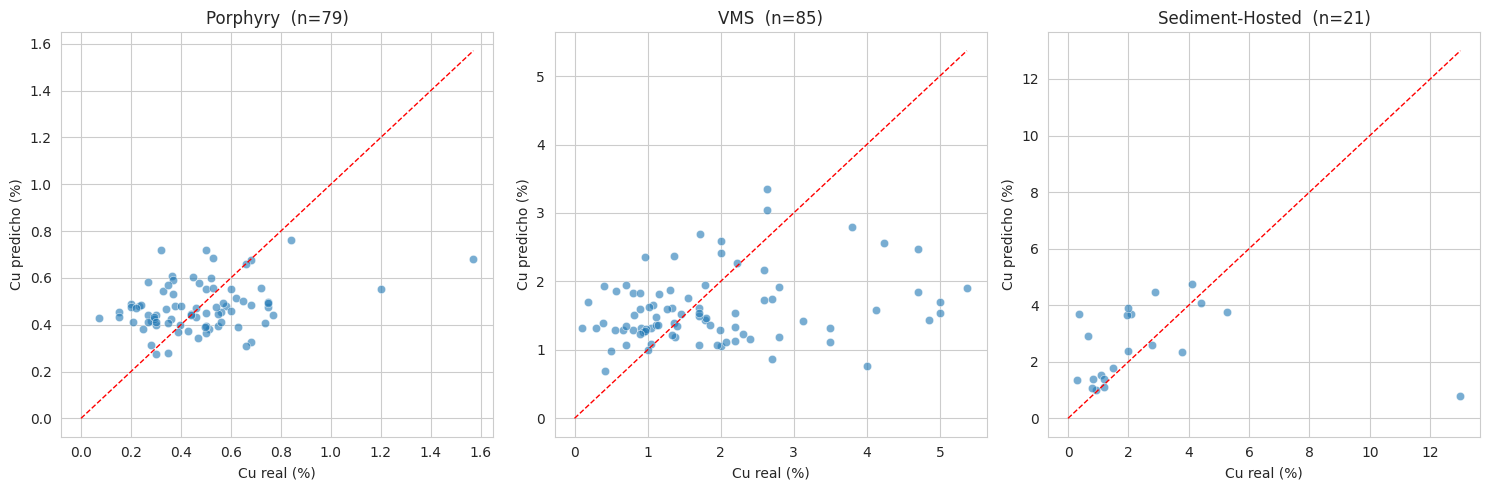

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, d in zip(axes, DOMAINS):
    m = (g_test == d).values
    ax.scatter(y_test[m], y_pred[m], alpha=0.6, edgecolor="white", linewidth=0.5)
    lim = max(y_test[m].max(), y_pred[m].max())
    ax.plot([0, lim], [0, lim], "r--", linewidth=1)
    ax.set_xlabel("Cu real (%)")
    ax.set_ylabel("Cu predicho (%)")
    ax.set_title(f"{d}  (n={m.sum()})")
plt.tight_layout()
plt.show()